# Instrumental Variables in Health Economics: Does Smoking During Pregnancy Lower Birth Weight?

This notebook is a second, independent IV case study — same method, completely different domain and dataset from the Card (1995) education/wages example. The goal here is twofold:

1. Show IV applied to a **health economics** question with a **continuous instrument** (price), rather than a binary geographic dummy.
2. Walk through what happens when **diagnostics reveal a weak instrument** — a critical, often-skipped part of real IV practice. Not every IV analysis "works," and knowing how to recognize and report a weak instrument is just as important as knowing how to run 2SLS.

**Research question:** What is the causal effect of maternal smoking during pregnancy on infant birth weight?

**The problem:** Mothers who smoke during pregnancy likely differ from non-smokers in other unobserved ways — risk tolerance, access to prenatal care, nutrition, stress — all of which could independently affect birth weight. A naive regression conflates smoking's effect with these confounders.

**The proposed instrument:** Mullahy (1997) and related literature use the **price of cigarettes in the mother's home state** as an instrument for smoking. The logic: higher cigarette prices should reduce smoking (a supply-side shifter), and a state's cigarette price shouldn't directly affect a baby's birth weight except through its effect on maternal smoking.

| Concept | Variable in this dataset |
|---|---|
| Outcome (Y) | `bwght` — birth weight, in ounces |
| Treatment (X) | `cigs` — average cigarettes smoked per day during pregnancy |
| Instrument (Z) | `cigprice` — cigarette price in the mother's home state (cents), 1988 |
| Confounders (U) | Unobserved: risk tolerance, nutrition, access to prenatal care, stress |

**Dataset:** 1,388 births from the 1988 National Health Interview Survey, originally compiled by Mullahy (1997) and distributed widely as the `bwght` dataset in Wooldridge's *Introductory Econometrics* teaching data. We pull it from the open-source [Rdatasets](https://github.com/vincentarelbundock/Rdatasets) mirror.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the Data

In [2]:
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/wooldridge/bwght.csv"
df = pd.read_csv(url)
df = df.drop(columns=["rownames"])
df.head()


,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,lbwght,bwghtlbs,packs,lfaminc
0,13.5000,16.5000,122.3000,109,12.0000,12.0000,1,1,1,0,4.6913,6.8125,0.0000,2.6027
1,7.5000,16.5000,122.3000,133,6.0000,12.0000,2,1,0,0,4.8903,8.3125,0.0000,2.0149
2,0.5000,16.5000,122.3000,129,NaN,12.0000,2,0,0,0,4.8598,8.0625,0.0000,-0.6931
3,15.5000,16.5000,122.3000,126,12.0000,12.0000,2,1,0,0,4.8363,7.8750,0.0000,2.7408
4,27.5000,16.5000,122.3000,134,14.0000,12.0000,2,1,1,0,4.8978,8.3750,0.0000,3.3142


In [3]:
print(f"Shape: {df.shape}")
df.info()


Shape: (1388, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   faminc    1388 non-null   float64
 1   cigtax    1388 non-null   float64
 2   cigprice  1388 non-null   float64
 3   bwght     1388 non-null   int64  
 4   fatheduc  1192 non-null   float64
 5   motheduc  1387 non-null   float64
 6   parity    1388 non-null   int64  
 7   male      1388 non-null   int64  
 8   white     1388 non-null   int64  
 9   cigs      1388 non-null   int64  
 10  lbwght    1388 non-null   float64
 11  bwghtlbs  1388 non-null   float64
 12  packs     1388 non-null   float64
 13  lfaminc   1388 non-null   float64
dtypes: float64(9), int64(5)
memory usage: 151.9 KB


**Variable dictionary:**

- `cigprice` — instrument: cigarette price in the mother's home state, in cents
- `cigtax` — an alternative candidate instrument: state cigarette excise tax
- `cigs` — treatment: average cigarettes smoked per day while pregnant
- `bwght` — outcome: birth weight in ounces
- `faminc`, `parity`, `male`, `white`, `motheduc`, `fatheduc` — controls

`fatheduc` has some missing values; since we won't use it as a control in our main model, we don't need to drop those rows. We do drop the single row missing `motheduc`.

In [4]:
df = df.dropna(subset=["motheduc"]).reset_index(drop=True)
print(f"Final analytic sample: {df.shape[0]} observations")
print(f"Mothers who smoked at all: {(df['cigs'] > 0).sum()} ({(df['cigs'] > 0).mean():.1%})")
df[["bwght", "cigs", "cigprice", "faminc", "parity"]].describe()


Final analytic sample: 1387 observations
Mothers who smoked at all: 212 (15.3%)


,bwght,cigs,cigprice,faminc,parity
count,1387.0000,1387.0000,1387.0000,1387.0000,1387.0000
mean,118.7080,2.0887,130.5620,29.0422,1.6330
std,20.3589,5.9746,10.2476,18.7371,0.8942
min,23.0000,0.0000,103.8000,0.5000,1.0000
25%,107.0000,0.0000,122.8000,15.0000,1.0000
50%,120.0000,0.0000,130.8000,27.5000,1.0000
75%,132.0000,0.0000,137.0000,37.5000,2.0000
max,271.0000,50.0000,152.5000,65.0000,6.0000


## 3. Why Not Just Run OLS?

Smoking status is a choice, and that choice is entangled with all sorts of other things that affect birth weight — nutrition, prenatal care, stress, genetics. A naive regression risks attributing some of that confounding to smoking itself.

In [5]:
ols_naive = smf.ols("bwght ~ cigs", data=df).fit()
print(ols_naive.summary())


                            OLS Regression Results                            
Dep. Variable:                  bwght   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     32.29
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.62e-08
Time:                        04:14:23   Log-Likelihood:                -6131.3
No. Observations:                1387   AIC:                         1.227e+04
Df Residuals:                    1385   BIC:                         1.228e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    119.7822      0.573    209.155      0.0

In [6]:
ols_controls = smf.ols(
    "bwght ~ cigs + parity + male + white + faminc",
    data=df
).fit()
print(ols_controls.summary())


                            OLS Regression Results                            
Dep. Variable:                  bwght   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     15.31
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.13e-14
Time:                        04:14:23   Log-Likelihood:                -6109.9
No. Observations:                1387   AIC:                         1.223e+04
Df Residuals:                    1381   BIC:                         1.226e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    108.8581      1.802     60.415      0.0

Both versions show a clear negative relationship — each additional cigarette per day is associated with roughly half an ounce less birth weight. This matches the broad medical literature. But is it causal, or partly confounded? Let's see if cigarette price can help us isolate the causal piece.

## 4. The Candidate Instrument: Cigarette Price

For `cigprice` to be a valid instrument, we need:

1. **Relevance** — higher cigarette prices reduce smoking during pregnancy (testable)
2. **Exclusion restriction** — cigarette price affects birth weight *only* through its effect on smoking, not directly (not directly testable, requires argument)
3. **Independence** — state cigarette prices are unrelated to unobserved confounders like maternal health behavior, conditional on controls (not directly testable, requires argument)

Let's visualize the relevance condition first, since that's the one we can actually check with data.

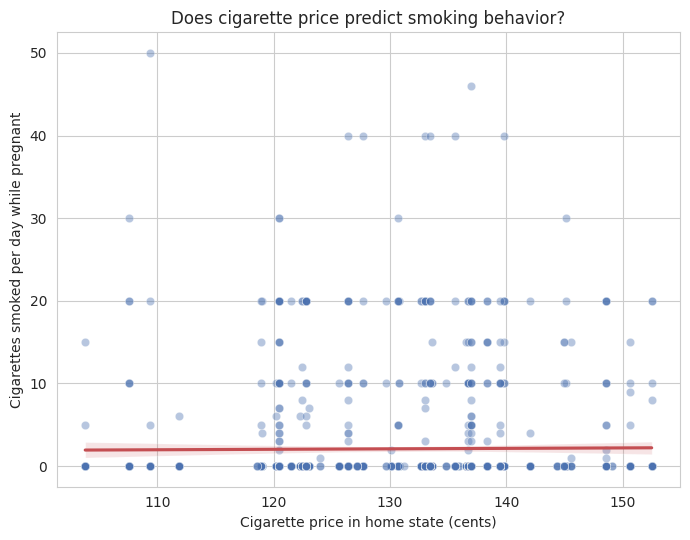

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(x="cigprice", y="cigs", data=df, alpha=0.4, ax=ax, color="#4C72B0")
sns.regplot(x="cigprice", y="cigs", data=df, scatter=False, ax=ax, color="#C44E52")
ax.set_xlabel("Cigarette price in home state (cents)")
ax.set_ylabel("Cigarettes smoked per day while pregnant")
ax.set_title("Does cigarette price predict smoking behavior?")
plt.tight_layout()
plt.show()


The fitted line is nearly flat. This is already a warning sign: in this particular cross-section, cigarette price doesn't appear to move smoking behavior much. Let's quantify that formally with the first stage regression before going any further.

## 5. Step 1 — First Stage: Does the Instrument Predict the Treatment?

In [8]:
first_stage = smf.ols(
    "cigs ~ cigprice + parity + male + white + faminc",
    data=df
).fit()
print(first_stage.summary())


                            OLS Regression Results                            
Dep. Variable:                   cigs   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     10.10
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.63e-09
Time:                        04:14:23   Log-Likelihood:                -4421.9
No. Observations:                1387   AIC:                             8856.
Df Residuals:                    1381   BIC:                             8887.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9654      2.048      0.471      0.6

In [9]:
restricted = smf.ols(
    "cigs ~ parity + male + white + faminc",
    data=df
).fit()

f_stat, p_value, df_diff = first_stage.compare_f_test(restricted)
print(f"Partial F-statistic on the instrument: {f_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print()
print("Rule of thumb: F > 10 suggests the instrument is not 'weak'.")
print("Here F is well under 1 -- this is a textbook weak instrument.")


Partial F-statistic on the instrument: 0.792
P-value: 0.3735

Rule of thumb: F > 10 suggests the instrument is not 'weak'.
Here F is well under 1 -- this is a textbook weak instrument.


**This is the key lesson of this notebook.** A partial F-statistic under 1 means cigarette price essentially has no detectable relationship with smoking behavior in this sample, once other factors are accounted for. This isn't a coding mistake — it's a real, well-documented feature of this dataset (state cigarette prices in a single year, 1988, don't vary enough across this particular cross-section of mothers to meaningfully shift their smoking behavior).

**What should we do when we discover a weak instrument?** We should *not* proceed to interpret the 2SLS coefficient as if it were reliable. Weak instruments are well known to produce IV estimates that are biased back toward OLS, have wildly inflated standard errors, and can even have the wrong sign in finite samples (Bound, Jaeger & Baker, 1995; Staiger & Stock, 1997). Let's see what happens if we proceed anyway, purely to illustrate why this matters.

## 6. What Happens If We Ignore the Weak Instrument Warning?

Let's run the full 2SLS anyway, so we can see firsthand what a weak-instrument result looks like — and contrast it with the diagnostics that warned us.

In [10]:
iv_model = IV2SLS.from_formula(
    "bwght ~ 1 + parity + male + white + faminc + [cigs ~ cigprice]",
    data=df
).fit(cov_type="robust")

print(iv_model.summary)


                          IV-2SLS Estimation Summary                          
Dep. Variable:                  bwght   R-squared:                     -1.5701
Estimator:                    IV-2SLS   Adj. R-squared:                -1.5794
No. Observations:                1387   F-statistic:                    21.920
Date:                Wed, Jun 17 2026   P-value (F-stat)                0.0005
Time:                        04:14:24   Distribution:                  chi2(5)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept      96.812     17.235     5.6171     0.0000      63.032      130.59
parity         0.0990     2.8803     0.0344     0.97

Notice what happened: the standard error on `cigs` exploded (compare it to the OLS standard error), the point estimate flipped sign and became implausibly large, and the confidence interval is so wide it includes both strongly negative and strongly positive effects. **None of this is informative.** This is the classic signature of a weak instrument — not a finding about smoking and birth weight, but an artifact of trying to extract a causal estimate from an instrument that barely moves the treatment.

In [11]:
print(iv_model.first_stage)


    First Stage Estimation Results    
                                  cigs
--------------------------------------
R-squared                       0.0353
Partial R-squared               0.0006
Shea's R-squared                0.0006
Partial F-statistic             0.7374
P-value (Partial F-stat)        0.3905
Partial F-stat Distn           chi2(1)
========================== ===========
Intercept                       0.9654
                              (0.4785)
parity                          0.3825
                              (1.6899)
male                           -0.1071
                             (-0.3406)
white                           0.5716
                              (1.2919)
faminc                         -0.0586
                             (-7.3637)
cigprice                        0.0138
                              (0.8587)
--------------------------------------

T-stats reported in parentheses
T-stats use same covariance type as original model


The `linearmodels` first-stage summary independently confirms what we already found: a partial F-statistic far below the conventional threshold for reliable inference.

## 7. Does a Different Instrument Help? Trying Cigarette Tax

The same dataset includes `cigtax`, the state cigarette excise tax — a closely related but distinct candidate instrument. Let's check whether it fares any better, and also check how correlated the two instruments are with each other (if they're nearly identical, this isn't really an independent check).

In [12]:
print("Correlation between cigtax and cigprice:")
print(df[["cigtax", "cigprice"]].corr())


Correlation between cigtax and cigprice:
          cigtax  cigprice
cigtax    1.0000    0.8761
cigprice  0.8761    1.0000


In [13]:
first_stage_tax = smf.ols(
    "cigs ~ cigtax + parity + male + white + faminc",
    data=df
).fit()

f_stat_tax, p_value_tax, _ = first_stage_tax.compare_f_test(restricted)
print(f"Partial F-statistic using cigtax: {f_stat_tax:.3f}  (p={p_value_tax:.4f})")


Partial F-statistic using cigtax: 1.057  (p=0.3041)


Unsurprisingly, since `cigtax` and `cigprice` are highly correlated with each other (tax is a major driver of retail price), `cigtax` is just as weak an instrument here. Swapping one for the other doesn't fix the underlying problem: in this single-year, single-survey cross-section, state-level price/tax variation doesn't translate into meaningfully different smoking behavior among these particular mothers.

## 8. Comparing All Estimates Side by Side

In [14]:
comparison = pd.DataFrame({
    "Method": [
        "OLS (no controls)",
        "OLS (with controls)",
        "2SLS / IV via cigprice (weak instrument -- unreliable)",
    ],
    "Estimate (oz per cigarette/day)": [
        ols_naive.params["cigs"],
        ols_controls.params["cigs"],
        iv_model.params["cigs"],
    ],
    "Std. Error": [
        ols_naive.bse["cigs"],
        ols_controls.bse["cigs"],
        iv_model.std_errors["cigs"],
    ],
})
comparison


,Method,Estimate (oz per cigarette/day),Std. Error
0,OLS (no controls),-0.5143,0.0905
1,OLS (with controls),-0.4907,0.0908
2,2SLS / IV via cigprice (weak instrument -- unr...,3.9274,6.3839


The IV standard error is roughly **70 times larger** than the OLS standard error — a direct, visible consequence of instrument weakness. This table is exactly the kind of result a careful analyst should **not** present as "the causal effect." The honest conclusion is: this particular instrument doesn't work for this particular sample, and a different identification strategy is needed.

## 9. What a Real Analysis Would Do Next

This is where a genuine empirical project would pivot. A few options the literature on smoking and birth weight has actually pursued:

- **Pool more states or years** of price/tax variation, since a single year may simply not have enough cross-state variation
- **Use sibling fixed-effects designs** comparing birth weights of siblings to the same mother, controlling for mother-level confounders directly rather than relying on an instrument at all
- **Use genetic instruments** (Mendelian randomization), exploiting genetic variants associated with nicotine metabolism as an instrument for smoking intensity
- **Report the weak-instrument-robust confidence sets** (e.g., Anderson-Rubin or conditional likelihood ratio confidence sets) instead of standard 2SLS standard errors, which remain valid even when the first stage is weak

The point isn't that IV "failed" as a method — it's that **this specific instrument, in this specific sample, doesn't satisfy the relevance condition strongly enough to trust.** Recognizing that and reporting it honestly is itself a core IV skill.

## 10. Key Takeaways

- IV requires a **strong first stage**, not just a plausible story. Always check the partial F-statistic before interpreting a 2SLS coefficient.
- A weak instrument doesn't just add noise — it can produce **biased, wrong-signed, and wildly imprecise** estimates that look superficially like real findings.
- Trying an alternative instrument that is **highly correlated with the original** (here, `cigtax` vs. `cigprice`) does not give you independent confirmation; check the correlation between candidate instruments before treating them as separate checks.
- A negative or inconclusive result that's reported honestly is more valuable to the field than a misleadingly "clean" 2SLS table built on a weak instrument.

### Further reading
- Mullahy, J. (1997). *Instrumental-Variable Estimation of Count Data Models: Applications to Models of Cigarette Smoking Behavior.* Review of Economics and Statistics.
- Evans, W.N. & Ringel, J.S. (1999). *Can higher cigarette taxes improve birth outcomes?* Journal of Public Economics.
- Bound, J., Jaeger, D.A., & Baker, R.M. (1995). *Problems with Instrumental Variables Estimation When the Correlation Between the Instruments and the Endogenous Explanatory Variable is Weak.* JASA.
- Staiger, D. & Stock, J.H. (1997). *Instrumental Variables Regression with Weak Instruments.* Econometrica.
